In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import glob

class AnimeFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        
        self.root_dir = root_dir
        self.transform = transform
        pattern = os.path.join(root_dir, '**', '*.*')
        self.img_names = [f for f in glob.glob(pattern, recursive=True) if f.endswith(('.png', '.jpg'))]

    def __len__(self):
        return len(self.img_names)
    
    def __str__(self):
        return f'AnimeFaceDataset with {len(self)} images from {self.root_dir}'

    def __getitem__(self, idx):
        img_path = self.img_names[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [4]:
dataset = AnimeFaceDataset(root_dir='/Users/almasm4pro/Desktop/dev/animeGAN/anime-faces', transform=transform)
print(dataset)

AnimeFaceDataset with 115085 images from /Users/almasm4pro/Desktop/dev/animeGAN/anime-faces


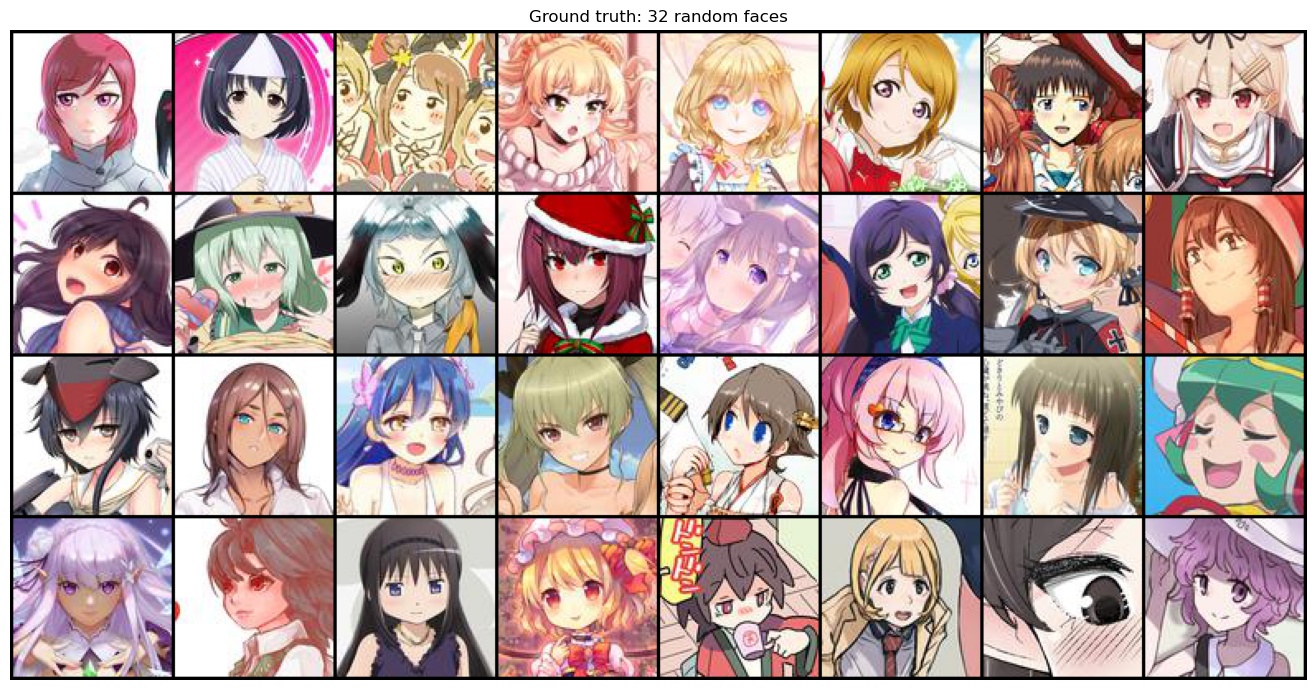

In [19]:
import random
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# 32 случайных ground truth (как сетка 4×8 у генератора)
random.seed(1223323223223322)
n = 32
idxs = random.sample(range(len(dataset)), n)
batch = torch.stack([dataset[i] for i in idxs])
grid = vutils.make_grid(batch, nrow=8, normalize=True, padding=2)

os.makedirs("generated_images", exist_ok=True)
vutils.save_image(grid, "generated_images/ground_truth_random32.png")

plt.figure(figsize=(14, 7))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Ground truth: 32 random faces")
plt.tight_layout()
plt.show()

In [ ]:
import multiprocessing

BATCH_SIZE = 128  
NUM_WORKERS = 8  

dataloader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS, 
    pin_memory=True,         
    drop_last=True           
)

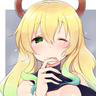

In [4]:
image = Image.open('/Users/almasm4pro/Desktop/dev/animeGAN/anime-faces/1girl/danbooru_2635680_1f250c3de677a69b2cbcdef34f06633b.jpg')
image

In [19]:
import torch.nn as nn
from torch.nn.utils import spectral_norm

    

class Generator(nn.Module):
    def __init__(self, z_dim=100, channels_img=3, features_g=64):
        super(Generator, self).__init__()

        def up_block(in_ch, out_ch, scale=2):
            return nn.Sequential(
                nn.Upsample(scale_factor=scale, mode='bilinear', align_corners=False),
                nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )
        self.gen = nn.Sequential(
            # Input: Z latent vector
            nn.ConvTranspose2d(z_dim, features_g * 16, kernel_size=6, stride=1, padding=0),
            nn.BatchNorm2d(features_g * 16),
            nn.ReLU(inplace=True),

            # 2. 6x6 -> 12x12
            up_block(features_g * 16, features_g * 8),
            
            # 3. 12x12 -> 24x24
            up_block(features_g * 8, features_g * 4),
            
            # 4. 24x24 -> 48x48
            up_block(features_g * 4, features_g * 2),
            
            # 5. 48x48 -> 96x96
            up_block(features_g * 2, features_g),

            # rewriting to RGB format
            nn.Conv2d(features_g, channels_img, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.gen(x)
    


# using LeakyReLU here to avoid dying relu
class Discriminator(nn.Module):
    def __init__(self, channels_img=3, features_d=64):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            # Input: 3 x 96 x 96
            nn.Conv2d(channels_img, features_d, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            # 48x48
            spectral_norm(nn.Conv2d(features_d, features_d * 2, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            # 24x24
            spectral_norm(nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            # 12x12
            spectral_norm(nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            # Final check: 6x6 -> 1x1
            nn.Conv2d(features_d * 8, 1, kernel_size=6, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x)


In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [28]:
from torchsummary import summary
gen = Generator(z_dim=100, channels_img=3, features_g=64).to(device)
disc = Discriminator(channels_img=3, features_d=64).to(device)



summary(gen, (100, 1, 1))

summary(disc, (3, 96, 96))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1           [-1, 1024, 6, 6]       3,687,424
       BatchNorm2d-2           [-1, 1024, 6, 6]           2,048
              ReLU-3           [-1, 1024, 6, 6]               0
          Upsample-4         [-1, 1024, 12, 12]               0
            Conv2d-5          [-1, 512, 12, 12]       4,719,104
       BatchNorm2d-6          [-1, 512, 12, 12]           1,024
              ReLU-7          [-1, 512, 12, 12]               0
          Upsample-8          [-1, 512, 24, 24]               0
            Conv2d-9          [-1, 256, 24, 24]       1,179,904
      BatchNorm2d-10          [-1, 256, 24, 24]             512
             ReLU-11          [-1, 256, 24, 24]               0
         Upsample-12          [-1, 256, 48, 48]               0
           Conv2d-13          [-1, 128, 48, 48]         295,040
      BatchNorm2d-14          [-1, 128,

In [ ]:
if torch.cuda.device_count() > 1:
    print(f"using {torch.cuda.device_count()} GPU!")
    gen = nn.DataParallel(gen)
    disc = nn.DataParallel(disc)

gen.to(device)
disc.to(device)

In [ ]:
import torch.optim as optim
import torchvision.utils as vutils
lr = 2e-4
batch_size = 128
num_workers = 8
z_dim = 100
num_epochs = 50
fixed_noise = torch.randn(32, z_dim, 1, 1).to(device)
SAVE_DIR = "generated_images"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs("weights2", exist_ok=True)
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()


for epoch in range(0, num_epochs):
    for batch_idx, real in enumerate(dataloader):
        real = real.to(device)
        curr_batch_size = real.size(0)

        # Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        noise = torch.randn(curr_batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)
        disc_real = disc(real).reshape(-1)
        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real) * 0.9)  # Label smoothing
        disc_fake = disc(fake.detach()).reshape(-1)
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        # Train Generator: min log(1 - D(G(z))) <-> max log(D(G(z)))
        output = disc(fake).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))
        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()
        
        if batch_idx % 300 == 0:
            print(f"Epoch [{epoch}/{num_epochs}] Batch {batch_idx}/{len(dataloader)} "
                  f"Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")
            
            with torch.no_grad():
                fake_display = gen(fixed_noise)
                img_grid = vutils.make_grid(fake_display[:32], normalize=True)
                vutils.save_image(img_grid, f"{SAVE_DIR}/epoch_{epoch}_batch_{batch_idx}.png")

    if epoch % 5 == 0 or epoch == num_epochs - 1:
        torch.save(gen.state_dict(), f"weights2/gen_epoch_{epoch}.pth")
        torch.save(disc.state_dict(), f"weights2/disc_epoch_{epoch}.pth")
        print(f"{epoch}'s epoch saved to /weights2")
    

taking the latest checkpint /content/gen_epoch_2.pth
Epoch [3/50] Batch 0/1799 Loss D: 0.2552, Loss G: 6.2480
Epoch [3/50] Batch 200/1799 Loss D: 0.2366, Loss G: 3.4963
Epoch [3/50] Batch 400/1799 Loss D: 0.2286, Loss G: 4.1490
Epoch [3/50] Batch 600/1799 Loss D: 0.2708, Loss G: 5.0160
Epoch [3/50] Batch 800/1799 Loss D: 0.2397, Loss G: 3.6968
Epoch [3/50] Batch 1000/1799 Loss D: 0.2245, Loss G: 4.0822
Epoch [3/50] Batch 1200/1799 Loss D: 0.2529, Loss G: 3.5507
Epoch [3/50] Batch 1400/1799 Loss D: 0.2566, Loss G: 3.7809
Epoch [3/50] Batch 1600/1799 Loss D: 0.2562, Loss G: 3.9097
Epoch [4/50] Batch 0/1799 Loss D: 0.2564, Loss G: 3.3490
Epoch [4/50] Batch 200/1799 Loss D: 0.4689, Loss G: 4.1144
Epoch [4/50] Batch 400/1799 Loss D: 0.2556, Loss G: 4.9210
Epoch [4/50] Batch 600/1799 Loss D: 0.2572, Loss G: 4.3937
Epoch [4/50] Batch 800/1799 Loss D: 0.2773, Loss G: 3.8208
Epoch [4/50] Batch 1000/1799 Loss D: 0.2518, Loss G: 4.1870
Epoch [4/50] Batch 1200/1799 Loss D: 0.3589, Loss G: 2.7713
E

/var/folders/4d/8b5xkxls3j1_q4rt0mqkv0gr0000gn/T/ipykernel_8342/508867576.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load("weights2/gen_epoch_49.pth

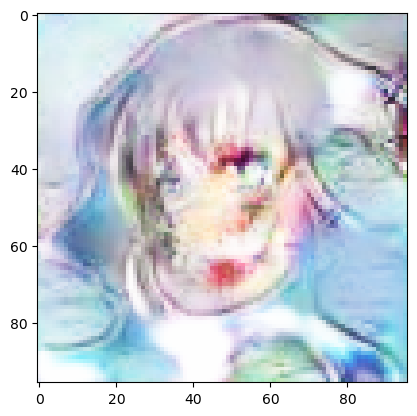

In [122]:
import torch
import matplotlib.pyplot as plt


weights = torch.load("weights2/gen_epoch_49.pth", map_location="cpu")

clean_weights = {k.replace("module.", ""): v for k, v in weights.items()}


gen.load_state_dict(clean_weights)
gen.eval() 

noise = torch.randn(1, 100, 1, 1)


with torch.no_grad():
    image = gen(noise)


img_to_show = image.squeeze().permute(1, 2, 0).numpy()
plt.imshow((img_to_show + 1) / 2) 
plt.show()